<a href="https://colab.research.google.com/github/nimitha123-kd/Take-IT-Smart-Internship/blob/main/Potato_Leaf_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Potato Leaf Disease Detection using Image Classification**

# 📄 Project Description / Problem Statement

This project focuses on building an image classification model to detect and classify potato plant
diseases. The dataset consists of high-resolution images of potato leaves categorized into three
classes: Early Blight, Late Blight, and Healthy leaves. The goal is to develop a robust deep
learning model that can accurately identify plant diseases and support agricultural diagnostics.


# 🎯 Objectives

● Understand image classification using deep learning

● Perform data preprocessing and augmentation

● Train and evaluate a CNN-based model

#📂 Dataset Details

**● Classes:**

○ Early Blight

○ Late Blight

○ Healthy

**● Data Type:**

- Image dataset (high-resolution leaf images)


**Load data from kaggle hub**

In [6]:
import kagglehub
# Download latest version
dataset_path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")
print("Path to dataset files:",dataset_path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Path to dataset files: /kaggle/input/potato-plant-diseases-data


**List all sub directories inside main folder**

In [7]:
import os
print(os.listdir(dataset_path))

['PlantVillage', 'PotatoPlants']


In [8]:
import matplotlib.pyplot as plt
from PIL import Image

for class_name in os.listdir(dataset_path):
  class_path = os.path.join(dataset_path,class_name)
  print(class_path)




/kaggle/input/potato-plant-diseases-data/PlantVillage
/kaggle/input/potato-plant-diseases-data/PotatoPlants


In [9]:
import matplotlib.pyplot as plt
from PIL import Image

for class_name in os.listdir(dataset_path):
  class_path = os.path.join(dataset_path,class_name)


  if os.path.isdir(class_path):
    images = os.listdir(class_path)[:5]# 0 to 5 images in each row.
    print(images)



['PlantVillage']
['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']


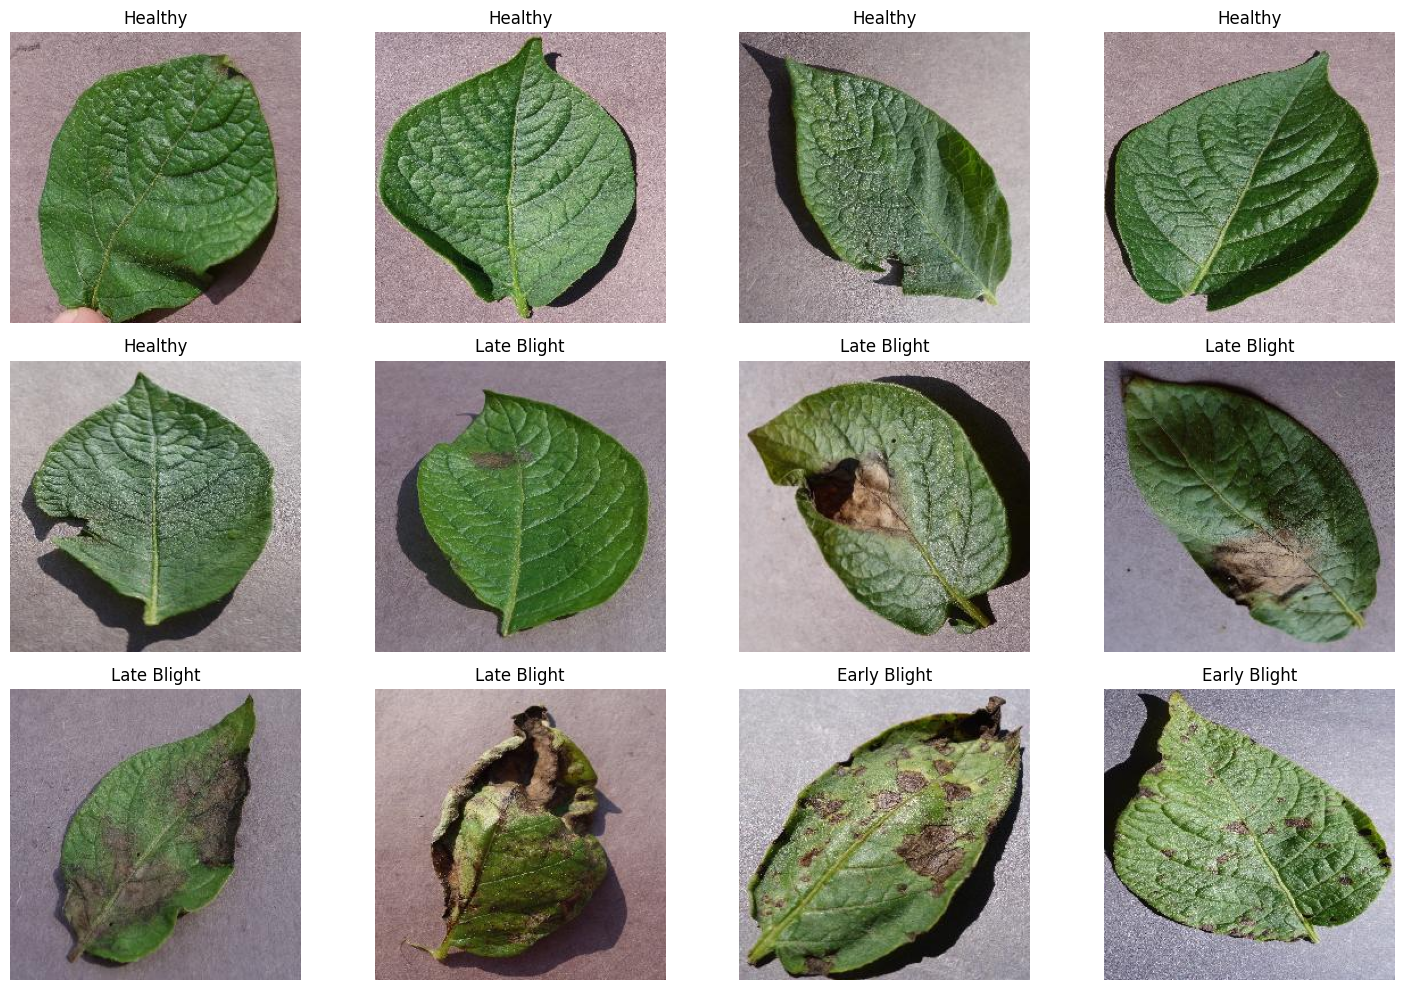

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

i = 0 # Counter for subplot position
plt.figure(figsize=(15, 10)) # Create a figure for all images

# Loop through the top-level directories in the dataset (e.g., 'PlantVillage', 'PotatoPlants')
for root_dir_name in os.listdir(dataset_path):
  root_dir_path = os.path.join(dataset_path, root_dir_name)

  if os.path.isdir(root_dir_path):
    # Loop through the subdirectories which are the actual disease classes
    for class_name in os.listdir(root_dir_path):
      class_path = os.path.join(root_dir_path, class_name)

      if os.path.isdir(class_path):
        # Get up to 5 image files from each class directory
        images_to_display = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))][:5]

        for img_filename in images_to_display:
          if i >= 12: # Limit to a maximum of 12 images for a 3x4 grid
            break

          full_img_path = os.path.join(class_path, img_filename)

          img_data = Image.open(full_img_path)
          plt.subplot(3, 4, i + 1) # Create a 3x4 grid, 1-based indexing for subplot
          plt.imshow(img_data)
          # Use the class_name for the title, making it more readable
          plt.title(class_name.replace('Potato___', '').replace('_', ' ').title())
          plt.axis('off')
          i += 1

      if i >= 12: # Break from inner loop if 12 images are already displayed
        break
  if i >= 12: # Break from outer loop if 12 images are already displayed
    break

plt.tight_layout()
plt.show()

In [50]:
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    count = len(os.listdir(class_path))
    print(count,'-->', class_name)


1 --> PlantVillage
3 --> PotatoPlants


 **create  a dataframe which includes img_path and label.**

In [12]:
# create a dataframe which includes img_path ,labels
import pandas as pd

data = []

# Loop through the top-level directories (e.g., 'PlantVillage', 'PotatoPlants')
for label in os.listdir(dataset_path):
    root_dir_path = os.path.join(dataset_path, root_dir_name)

    if os.path.isdir(root_dir_path):
        # Loop through the actual disease class folders (e.g., 'Potato___healthy')
        for disease_class_name in os.listdir(root_dir_path):
            disease_class_path = os.path.join(root_dir_path, disease_class_name)

            if os.path.isdir(disease_class_path):
                # Loop through the actual image files within each class folder
                for img_filename in os.listdir(disease_class_path):
                    img_path = os.path.join(disease_class_path, img_filename)
                    data.append([img_path, disease_class_name])

df = pd.DataFrame(data, columns=["image_path", "label"])
df

,image_path,label
0,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
1,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
2,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
3,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
4,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
...,...,...
4299,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
4300,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
4301,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
4302,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight


# shuffle the images.

In [13]:
df = df.sample(frac=1,random_state=42).reset_index(drop=True)#frac=1 → selects 100% of the rows (i.e., the entire dataset, but shuffled if random_state is set).
df

,image_path,label
0,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
1,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
2,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
3,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
4,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
...,...,...
4299,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
4300,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
4301,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
4302,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight


**Split data for training ,testing and Validation**

In [14]:
train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))
test_size = int(0.15*len(data))
print(f"train_size:{train_size} -----val_size:{val_size}----test_size:{test_size}")

train_data = df.iloc[:train_size]
# data.iloc[:,52500]
val_data =df.iloc[train_size:train_size + val_size]
# data.iloc[52500:52500+11250]
test_data = df.iloc[train_size + val_size:]
# data.iloc[52500+11250:]

# Display the sizes of each set
print(f'Training set size: {len(train_data)}')
print(f'Validation set size: {len(val_data)}')
print(f'Test set size: {len(test_data)}')

train_size:3012 -----val_size:645----test_size:645
Training set size: 3012
Validation set size: 645
Test set size: 647


In [15]:
image_p = df["image_path"][0]
image = Image.open(full_img_path)
width, height = image.size
print(f"height,width:{height,width}")

height,width:(256, 256)


In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
batch_size = 32
img_height = 224
img_width = 224

In [18]:
# Normalization
data_generator = ImageDataGenerator(
    rescale=1.0/255, # Normalization: Pixel values go from 0–255 → 0–1
    rotation_range=40, #Randomly rotates image up to ±40 degrees
    width_shift_range=0.2, #Moves image left/right by 20%
    height_shift_range=0.2, # Moves image up/down by 20%
    shear_range=0.2, # Slants the image (like pushing it sideways)
    zoom_range=0.2, # Zoom in/out randomly
    horizontal_flip=True, #Flips image left ↔ right
    fill_mode='nearest' #This fills those gaps using nearest pixels
)

In [19]:
# train data
train_generator = data_generator.flow_from_dataframe(
  dataframe=train_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 3012 validated image filenames belonging to 3 classes.


In [20]:
# test generator
test_generator = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 647 validated image filenames belonging to 3 classes.


In [21]:
# validation generator
validation_generator = data_generator.flow_from_dataframe(
  dataframe=val_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 645 validated image filenames belonging to 3 classes.


In [22]:
for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in validation_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(validation_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 224, 224, 3) (Batches = 95)
Train Label Shape: (32, 3)

Validation Shape: (32, 224, 224, 3) (Batches = 21)
Validation Label Shape: (32, 3)

Test Shape: (32, 224, 224, 3) (Batches = 21)
Test Label Shape: (32, 3)



#MODEL BUILDING

In [23]:
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy

In [24]:
n_classes= 3 # Changed  to 3 to match the number of classes in the dataset
cnn_model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size= (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax')]) # Changed activation to 'softmax' for multi-class classification

In [25]:
cnn_model.compile(loss=binary_crossentropy,
                  optimizer=Adam(),
                  metrics=['accuracy'])

In [26]:
Cnn = cnn_model.fit(train_generator,
                    epochs=50,validation_data=validation_generator,
                    verbose=1)

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.6471 - loss: 0.4295 - val_accuracy: 0.8605 - val_loss: 0.1894
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.8914 - loss: 0.1836 - val_accuracy: 0.8837 - val_loss: 0.1955
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.9475 - loss: 0.0962 - val_accuracy: 0.9426 - val_loss: 0.1132
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 353s 4s/step - accuracy: 0.9542 - loss: 0.0826 - val_accuracy: 0.9535 - val_loss: 0.0835
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 350s 4s/step - accuracy: 0.9575 - loss: 0.0782 - val_accuracy: 0.9705 - val_loss: 0.0630
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 350s 4s/step - accuracy: 0.9648 - loss: 0.0709 - val_accuracy: 0.9550 - val_loss: 0.0718
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.9572 - loss: 0.0800 - val_accuracy: 0.9628 - val_loss: 0.0633
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 350s 4s/step - accuracy: 0.9565 - loss: 0.0848 - val_accuracy: 0.9736 - v

# MODEL TRAINING

In [27]:
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

95/95 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9904 - loss: 0.0225
Training accuracy: 0.9904
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9845 - loss: 0.0344
Test accuracy: 0.9845


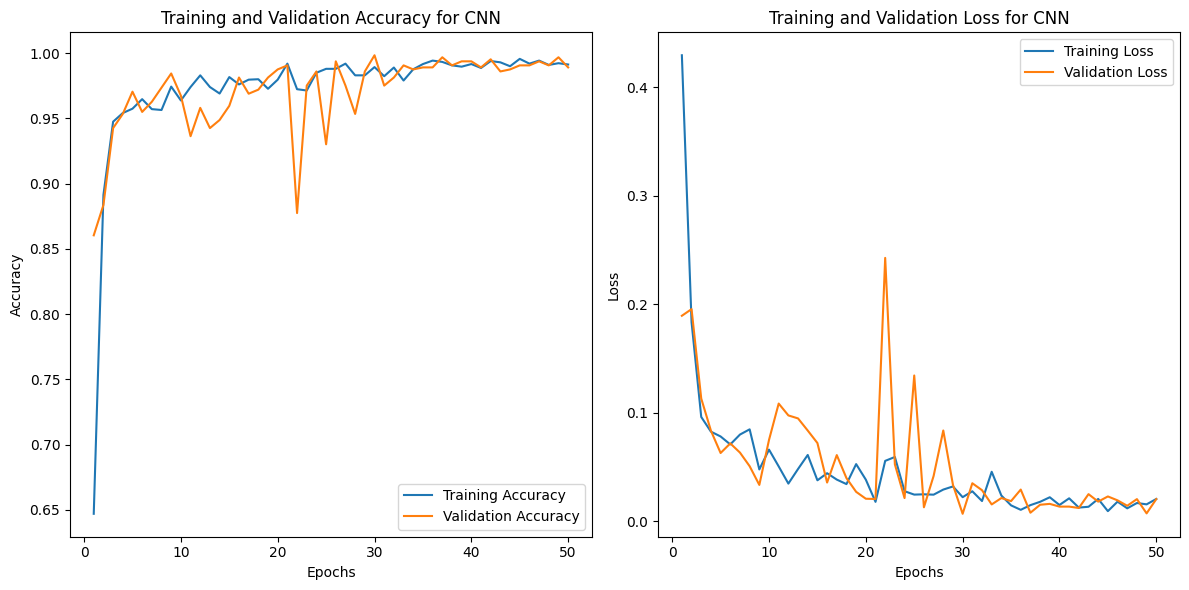

In [28]:
# Retrieve metrics from the training history
acc = Cnn.history['accuracy']
val_acc = Cnn.history['val_accuracy']
loss = Cnn.history['loss']
val_loss = Cnn.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for CNN')
plt.legend()

plt.tight_layout()
plt.show()

# Take a potato leaf disease image from the google and upload to check whether the image selected has disease or not.

In [30]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "Potato_leaf.jpg"

# Load image
img = image.load_img(img_path, target_size=(224, 224))  # same as training

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

In [32]:
prediction = cnn_model.predict(img_array)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


array([[1.0000000e+00, 1.1923825e-29, 0.0000000e+00]], dtype=float32)

In [34]:
predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)

Predicted Class: 0


In [35]:
class_names = list(train_generator.class_indices.keys())
predicted_class_name = class_names[predicted_class]
print(f"The predicted class is: {predicted_class_name}")

The predicted class is: Potato___Early_blight


# Model Evaluation.

Found 647 validated image filenames belonging to 3 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step
Overall Accuracy: 0.98145285935085
Classification Report:
                        precision    recall  f1-score   support

Potato___Early_blight       0.98      1.00      0.99       293
 Potato___Late_blight       1.00      0.96      0.98       317
     Potato___healthy       0.84      1.00      0.91        37

             accuracy                           0.98       647
            macro avg       0.94      0.99      0.96       647
         weighted avg       0.98      0.98      0.98       647



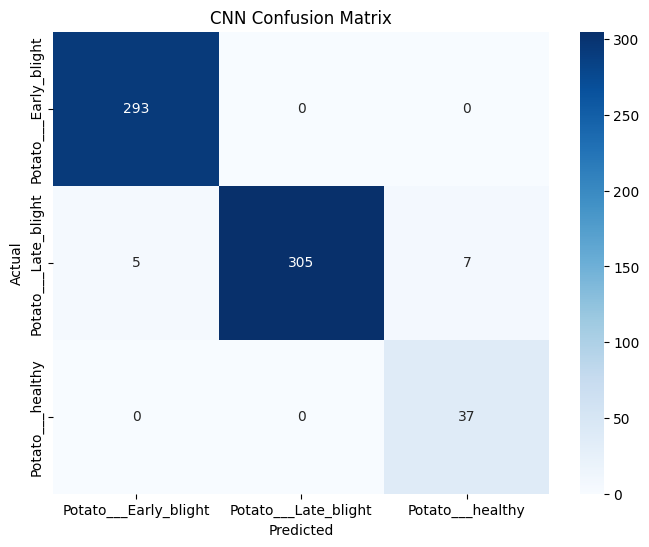

In [49]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Create a separate generator for the test set without shuffling
# This is crucial for aligning predictions with true labels
test_generator_for_eval = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=False, # Do not shuffle for evaluation to match true labels
  seed=42
)

# 1. Get predictions from your CNN model
predictions = cnn_model.predict(test_generator_for_eval)
# 'y_pred' converts probabilities to class indices (e.g., [0, 1, 2]), label encoding.
y_pred = np.argmax(predictions, axis=1)

# 2. Get true labels from the generator
y_true = test_generator_for_eval.classes

# 3. Calculate and print Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy:",accuracy)

# 4. Generate the Classification Report
# Includes Precision, Recall, F1-Score for each class
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

# 5. Create and Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.show()

#**BUSINESS INSIGHTS**

- Early detection reduces crop loss and improves yield stability.

- Automated prediction minimizes human error compared to manual inspection.

- Targeted pesticide usage lowers operational and chemical costs.

- Scalable deployment via mobile/edge devices supports large farm monitoring.

- Improves farmer ROI through increased productivity and reduced losses.

- Enables data-driven decision-making using historical prediction data.

- Optimizes resource utilization (water, fertilizer, chemicals).

- Integrates with IoT/drones for precision agriculture systems.

#**📝CONCLUSION**
The project successfully applies deep learning to classify potato leaf conditions into disease categories with high accuracy.
Evaluation through confusion matrix and classification report confirms reliable performance across classes. This approach demonstrates the potential in early disease detection, reducing crop loss and supporting sustainable farming.
Limitations remain in dataset diversity, requiring continuous updates for real-world deployment.
Overall, the model provides a strong foundation for agricultural decision support systems.